# Notebook 5: Liver Disease Prediction
**Dataset**: Indian Liver Patient Dataset — UCI ML Repository
**Target**: Dataset (1 = Liver Patient, 2 = Non-Patient)
**Model**: XGBoost Classifier + GridSearchCV Tuning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')

Libraries loaded


## Step 1: Load Data

In [2]:
df = pd.read_csv('../datasets/indian_liver_patient.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
print('\nClass distribution:\n', df.iloc[:,-1].value_counts())
df.head()

Shape: (583, 11)
Columns: ['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Dataset']

Class distribution:
 Dataset
1    416
2    167
Name: count, dtype: int64


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## Step 2: EDA

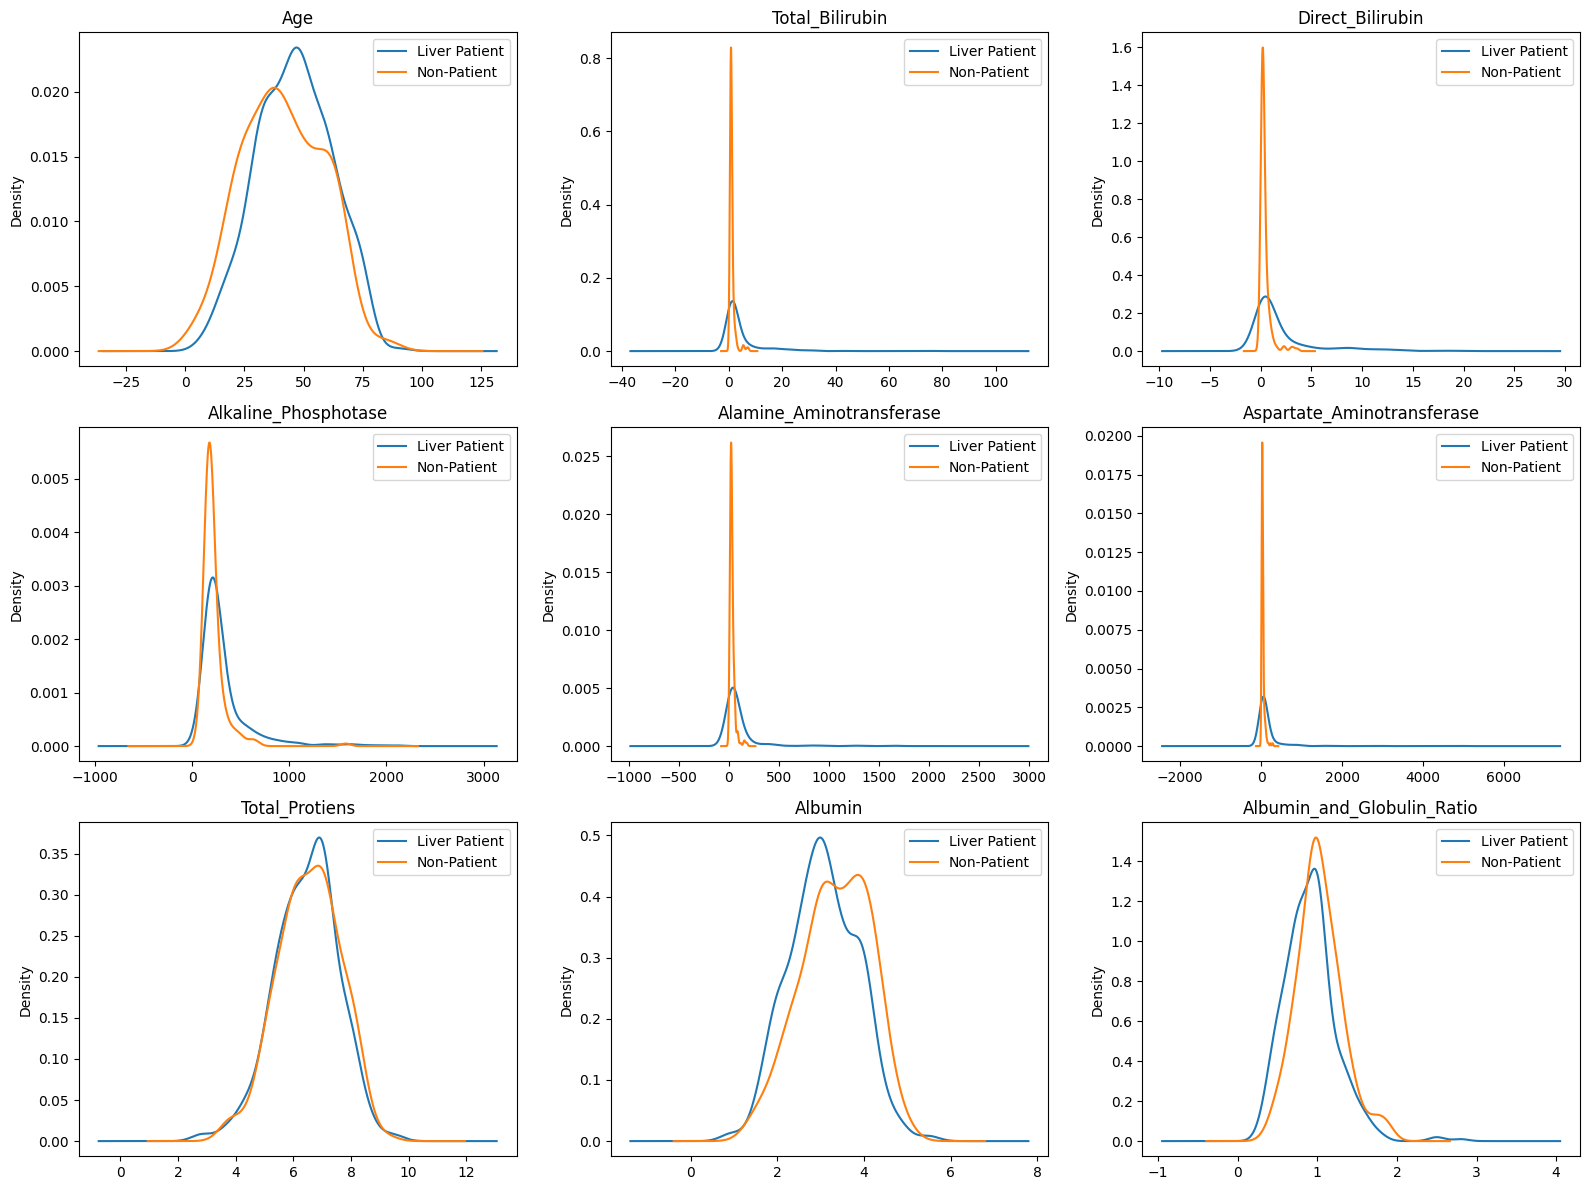

In [3]:
target_col = df.columns[-1]
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target_col]
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for i, col in enumerate(num_cols[:9]):
    ax = axes[i//3][i%3]
    df.groupby(target_col)[col].plot(kind='kde', ax=ax)
    ax.set_title(col)
    ax.legend(['Liver Patient','Non-Patient'])
plt.tight_layout()
plt.show()

## Step 3: Preprocessing

In [4]:
if 'Gender' in df.columns:
    df['Gender'] = LabelEncoder().fit_transform(df['Gender'].astype(str))
df[target_col] = df[target_col].map({1:1, 2:0})
df.fillna(df.median(numeric_only=True), inplace=True)
X = df.drop(target_col, axis=1)
y = df[target_col]
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (665, 10), Test: (167, 10)


## Step 4: Baseline Model

In [5]:
baseline = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:,1])
print(f'Baseline Accuracy : {baseline_acc:.4f}')
print(f'Baseline ROC-AUC  : {baseline_auc:.4f}')

Baseline Accuracy : 0.8263
Baseline ROC-AUC  : 0.9134


## Step 5: Hyperparameter Tuning (GridSearchCV)

In [6]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV ROC-AUC:', f'{grid_search.best_score_:.4f}')

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.8748


## Step 6: Tuned Model Evaluation

In [7]:
model = grid_search.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
tuned_acc = accuracy_score(y_test, y_pred)
tuned_auc = roc_auc_score(y_test, y_prob)
print(f'Tuned Accuracy : {tuned_acc:.4f}  (Baseline: {baseline_acc:.4f})  Gain: {tuned_acc - baseline_acc:+.4f}')
print(f'Tuned ROC-AUC  : {tuned_auc:.4f}  (Baseline: {baseline_auc:.4f})  Gain: {tuned_auc - baseline_auc:+.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred, target_names=['Non-Patient','Liver Patient']))

Tuned Accuracy : 0.8443  (Baseline: 0.8263)  Gain: +0.0180
Tuned ROC-AUC  : 0.9127  (Baseline: 0.9134)  Gain: -0.0007

Classification Report:
                precision    recall  f1-score   support

  Non-Patient       0.83      0.87      0.85        84
Liver Patient       0.86      0.82      0.84        83

     accuracy                           0.84       167
    macro avg       0.85      0.84      0.84       167
 weighted avg       0.85      0.84      0.84       167



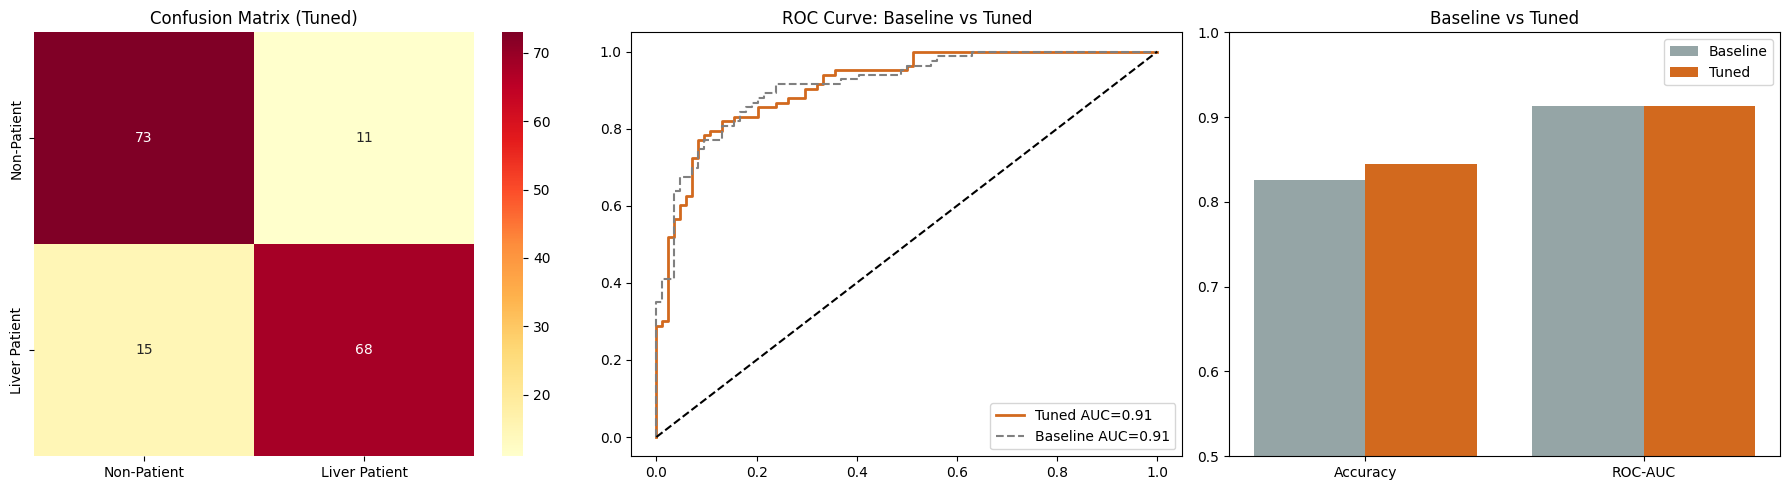

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['Non-Patient','Liver Patient'], yticklabels=['Non-Patient','Liver Patient'])
axes[0].set_title('Confusion Matrix (Tuned)')
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='chocolate', lw=2, label=f'Tuned AUC={tuned_auc:.2f}')
fpr_b, tpr_b, _ = roc_curve(y_test, baseline.predict_proba(X_test)[:,1])
axes[1].plot(fpr_b, tpr_b, color='gray', lw=1.5, linestyle='--', label=f'Baseline AUC={baseline_auc:.2f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title('ROC Curve: Baseline vs Tuned')
axes[1].legend()
x = np.arange(2)
axes[2].bar(x-0.2, [baseline_acc, baseline_auc], 0.4, label='Baseline', color='#95a5a6')
axes[2].bar(x+0.2, [tuned_acc, tuned_auc], 0.4, label='Tuned', color='chocolate')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Accuracy','ROC-AUC'])
axes[2].set_ylim(0.5, 1.0)
axes[2].set_title('Baseline vs Tuned')
axes[2].legend()
plt.tight_layout()
plt.show()

## Step 7: Save Model

In [9]:
joblib.dump(model, '../models/liver_model.pkl')
joblib.dump(scaler, '../models/liver_scaler.pkl')
print('Liver tuned model and scaler saved!')

Liver tuned model and scaler saved!
